In [ ]:
import random
import uuid
import numpy as np
import pandas as pd
import torch
from torchvision import transforms
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import warnings

import os
import shutil
from tqdm import tqdm

from transformers import AutoModelForZeroShotObjectDetection, AutoProcessor, CLIPProcessor, CLIPModel
from segment_anything import SamPredictor, sam_model_registry
import gc

import qdrant_client
from qdrant_client.http import models
from qdrant_client.models import VectorParams
from qdrant_client.http.models import Filter, SearchRequest, FieldCondition, Range
import clip

## Визуализация точек на изображении

In [ ]:
!ls ../Monocular/

In [ ]:
base_path = "../../datasets/collected_data_long_60fps"

In [ ]:
os.listdir(base_path)

In [ ]:
data_path = os.path.join(base_path, "collected_data.csv")
points_path = os.path.join(base_path, "collected_data_points.csv")
images_path = os.path.join(base_path, "images/")

df_data = pd.read_csv(data_path)
df_points = pd.read_csv(points_path)

In [ ]:
os.listdir(images_path)[:10]

In [ ]:
df_data.head()

In [ ]:
df_data.loc[0, ["camera_x", "camera_y", "camera_z"]].tolist()

In [ ]:
df_data.loc[1, ["camera_x", "camera_y", "camera_z"]].tolist()

Как видно из данных координат камеры, числовая точность у осей очень большая, это может вызывать шум траектории транспорта.  
По идее, если уменьшить точность чисел и округлять их, траектория получится плавнее. Этот способ можно будет применить в дополнение к корректировке по зданиям.

In [ ]:
df_data.info()

In [ ]:
df_points.columns.to_list()

In [ ]:
df_points[df_points["frame_idx"] == 0].head()

In [ ]:
images = os.listdir(images_path)

In [ ]:
images[0]

In [ ]:
img_name = df_data.loc[0, "image_filename"]
img_name

In [ ]:
img = cv2.imread(os.path.join(images_path, img_name))

In [ ]:
plt.figure(figsize=(10, 16))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
df_points[df_points["frame_idx"] == 0].to_dict(orient="records")[:2]

Изменённая функция из receive_data.py:

In [ ]:
def visualize_points_on_frame(frame: np.ndarray, points):
    """
    Отрисовка точек на изображении
    
    Args:
        frame: Изображение для отрисовки
        points: Список словарей с ключевыми точками
    """
    plt.clf()
    color = (230, 160, 121)
    frame_copy = frame.copy()
    plt.figure(figsize=(10, 16))

    for point in points:
        try:
            x, y = int(point["image_x"]), int(point["image_y"])

            cv2.circle(frame_copy, (x, y), 4, color, -1)

        except Exception as e:
            print("Ошибка при отрисовке точки:", e)

    frame_rgb = cv2.cvtColor(frame_copy, cv2.COLOR_BGR2RGB)

    plt.imshow(frame_rgb)
    plt.axis('off')
    frame_name = df_data.loc[df_data["frame_idx"] == point["frame_idx"], "image_filename"]
    plt.title(f"Ключевые точки для кадра {frame_name}")
    plt.show()

In [ ]:
df_data.head()

In [ ]:
visualize_points_on_frame(img, df_points[df_points["frame_idx"] == 0].to_dict(orient="records"))

In [ ]:
def get_frame_data(idx):
    img_name = df_data.loc[df_data["frame_idx"] == idx, "image_filename"].values[0]
    img_path = os.path.join(images_path, img_name)
    img = cv2.imread(img_path)
    points = df_points[df_points["frame_idx"] == idx].to_dict(orient="records")
    
    return img_path, img, points

In [ ]:
for idx in range(10):
    _, img, points = get_frame_data(idx)
    visualize_points_on_frame(img, points)

Из собранных данных можно сделать вывод: на зданиях ORB-SLAM3 отмечает очень мало точек.  
Если в таком виде сопоставлять их с выводом модели SAM, практически ничего не будет записано в базу данных. А если сопоставлять точки с боксами Grounding Dino, точность местоположения зданий будет низкой, так как на боксы наложатся точки с других объектов (из-за перекрытий).

___

## Проверка на собранных данных Grounding DINO + SAM

In [ ]:
os.environ["TORCH_CUDA_ARCH_LIST"] = "8.6+PTX"

In [ ]:
sam_checkpoint = "weights/sam_vit_h_4b8939.pth"
sam = sam_model_registry["vit_h"](checkpoint=sam_checkpoint).to("cuda")
predictor = SamPredictor(sam)

In [ ]:
dino_processor_tiny = AutoProcessor.from_pretrained("IDEA-Research/grounding-dino-tiny")
dino_model_tiny = AutoModelForZeroShotObjectDetection.from_pretrained("IDEA-Research/grounding-dino-tiny").to("cuda")

In [ ]:
def segment_buildings(image, boxes):
    """Выделение зданий с помощью SAM"""
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    predictor.set_image(image_rgb)

    masks = []

    for box in boxes:
        mask, _, _ = predictor.predict(box=box.astype(int))
        masks.append(mask[0])
    
    return masks

In [ ]:
def segment_buildings(image, boxes):
    """Выделение зданий с помощью SAM"""
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    predictor.set_image(image_rgb)

    masks = []

    for box in boxes:
        mask, _, _ = predictor.predict(box=box.astype(int))
        masks.append(mask[0])
    
    return masks

def show_mask(mask, ax, color=(0, 0, 1)):
    """Функция для наложения маски на изображение"""
    mask = mask.astype(np.uint8)
    mask_image = np.zeros((*mask.shape, 4))
    mask_image[:, :, 0] = color[0]  # R
    mask_image[:, :, 1] = color[1]  # G
    mask_image[:, :, 2] = color[2]  # B
    mask_image[:, :, 3] = mask * 0.5  # Прозрачность
    
    ax.imshow(mask_image)

def visualize_results(image, boxes, masks):
    """Функция для отрисовки боксов и масок"""
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(image_rgb)

    # Отрисовка боксов
    for box in boxes:
        x_min, y_min, x_max, y_max = box.astype(int)
        ax.add_patch(plt.Rectangle(
            (x_min, y_min), x_max - x_min, y_max - y_min,
            edgecolor="red", linewidth=2, fill=False))

    # Случайные цвета
    for mask in masks:
        color = (random.random(), random.random(), random.random())
        show_mask(mask, ax, color=color)

    ax.axis("off")
    plt.title("Выделение зданий (Grounding DINO + SAM)")
    plt.show()

In [ ]:
def visualize_results(image, boxes, masks):
    """Функция для отрисовки боксов и масок"""
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(image_rgb)

    # Отрисовка боксов
    for box in boxes:
        x_min, y_min, x_max, y_max = box.astype(int)
        ax.add_patch(plt.Rectangle(
            (x_min, y_min), x_max - x_min, y_max - y_min,
            edgecolor="red", linewidth=2, fill=False))

    # Случайные цвета
    for mask in masks:
        color = (random.random(), random.random(), random.random())
        show_mask(mask, ax, color=color)

    ax.axis("off")
    plt.title("Выделение зданий (Grounding DINO + SAM)")
    plt.show()

In [ ]:
def segment_image(image_path, image, visualize=True):
    text_labels = ["building"]
    image_pil = Image.open(image_path)
    inputs = dino_processor_tiny(images=image_pil, text=text_labels, return_tensors="pt").to("cuda")
    
    with torch.no_grad():
        outputs = dino_model_tiny(**inputs)
    
    results = dino_processor_tiny.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=0.3,
        target_sizes=[image_pil.size[::-1]]
    )
    
    boxes = results[0]["boxes"].cpu().numpy()
    masks = segment_buildings(image, boxes)
    
    print(f"Количество найденных объектов: {len(boxes)}")

    if visualize:
        visualize_results(image, boxes, masks)

In [ ]:
img_path, img, points = get_frame_data(0)
segment_image(img_path, img)

In [ ]:
img_path, img, points = get_frame_data(10)
segment_image(img_path, img)

In [ ]:
img_path, img, points = get_frame_data(20)
segment_image(img_path, img)

In [ ]:
img_path, img, points = get_frame_data(40)
segment_image(img_path, img)

In [ ]:
img_path, img, points = get_frame_data(70)
segment_image(img_path, img)

In [ ]:
img_path, img, points = get_frame_data(99)
segment_image(img_path, img)

SAM отрабатывает ужасно в тёмных местах, с перекрытиями и с наложением сложных форм. Здесь определённо нужна другая модель, которая подойдёт для городской среды. Работа Grounding DINO хорошая, но с вложенными боксами координата здания будет неточной.  
С другой стороны, работать с настолько зашумленными данными по-другому будет сложно.  

Можно разработать следующее решение:  
- Получить боксы и маски
- Каким-то образом удалить из каждого бокса (логическая разность) другие пересекающиеся боксы. При этом нужно определить главный бокс и перекрывающие. Просто оставление по наибольшей площади не подойдёт, так как не перекрывающий бокс может получать преимущество в прямоугольнике, но не являться целью обводки.
- В конце извлечь только из полученной части точное выделение SAM и определить координаты точек ORB-SLAM3.

Возможно, есть смысл итеративно проходить по всем боксам на кадре, начиная с самого маленького, и вычитать из него другие боксы. Помечать эту часть изображения как обработанную и не собирать в следующих боксах.

In [ ]:
def visualize_results_step_by_step(image, boxes):
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_mask = np.zeros(image.shape[:2], dtype=np.uint8)
    image_copy = image.copy()

    boxes = sorted(boxes, key=lambda x: (x[2] - x[0]) * (x[3] - x[1]))

    for i, box in enumerate(boxes):
        x_min, y_min, x_max, y_max = box.astype(int)

        box_mask = np.zeros_like(image_mask)
        cv2.rectangle(box_mask, (x_min, y_min), (x_max, y_max), 255, -1)

        overlap = cv2.bitwise_and(box_mask, image_mask)
        new_area = cv2.bitwise_xor(box_mask, overlap)

        if np.count_nonzero(new_area) > 0:
            image_mask = cv2.bitwise_or(image_mask, new_area)

            image_copy[new_area > 0] = (0, 0, 0)

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.imshow(cv2.cvtColor(image_copy, cv2.COLOR_BGR2RGB))
        rect = plt.Rectangle(
            (x_min, y_min), x_max - x_min, y_max - y_min,
            edgecolor="red", linewidth=2, fill=False
        )
        ax.add_patch(rect)
        ax.set_title(f"Шаг {i + 1}: обработка бокса ({x_min}, {y_min}) → ({x_max}, {y_max})")
        ax.axis("off")
        plt.show()

def segment_image(image_path, image, visualize=True):
    text_labels = ["building"]
    image_pil = Image.open(image_path)
    inputs = dino_processor_tiny(images=image_pil, text=text_labels, return_tensors="pt").to("cuda")
    
    with torch.no_grad():
        outputs = dino_model_tiny(**inputs)
    
    results = dino_processor_tiny.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=0.3,
        target_sizes=[image_pil.size[::-1]]
    )
    
    boxes = results[0]["boxes"].cpu().numpy()
    
    print(f"Количество найденных объектов: {len(boxes)}")

    if visualize:
        visualize_results_step_by_step(image, boxes)

In [ ]:
img_path, img, points = get_frame_data(0)
segment_image(img_path, img)

Подобный подход убирает слишком большие части из боксов и не решает проблему перекрытий.  
2 предложенных решения не совсем подойдут, так как невозможно до точной сегментации только по боксам определить, какое здание находится спереди, а какое сзади.

После ещё одного анализа была выдвинута гипотеза: возможно, цвета сегментации SAM перекрывают сегментации для других боксов, из-за чего всё и кажется "рваным" и неточным. Нужно это проверить:

In [ ]:
def iterative_visualize_frame(image, boxes, masks):
    for i in np.argsort([np.prod(box[2:] - box[:2]) for box in boxes]):
        box = boxes[i].astype(int)
        mask = masks[i].astype(bool)
        color = (random.random(), random.random(), random.random())

        image_rgb = cv2.cvtColor(image.copy(), cv2.COLOR_BGR2RGB)
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.imshow(image_rgb)

        x_min, y_min, x_max, y_max = box
        ax.add_patch(plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                                   edgecolor="red", linewidth=2, fill=False))
        show_mask(mask, ax, color=color)
        ax.axis("off")
        plt.title(f"Здание {i + 1}")
        plt.show()

In [ ]:
def segment_image_iterative(image_path, image, visualize=True):
    text_labels = ["building"]
    image_pil = Image.open(image_path)
    inputs = dino_processor_tiny(images=image_pil, text=text_labels, return_tensors="pt").to("cuda")
    
    with torch.no_grad():
        outputs = dino_model_tiny(**inputs)
    
    results = dino_processor_tiny.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=0.3,
        target_sizes=[image_pil.size[::-1]]
    )
    
    boxes = results[0]["boxes"].cpu().numpy()
    masks = segment_buildings(image, boxes)
    
    print(f"Количество найденных объектов: {len(boxes)}")

    if visualize:
        iterative_visualize_frame(image, boxes, masks)

In [ ]:
img_path, img, points = get_frame_data(0)
segment_image_iterative(img_path, img)

Проблемными были замечены 40-ой и 70-ый кадр.  
Проверка, действительно ли у них плохая обработка, либо же цвета перекрылись и создали путаницу:

In [ ]:
img_path, img, points = get_frame_data(40)
segment_image_iterative(img_path, img)

Здесь всё же замечена неправильная обводка. Значит, всё же нужно вычитать уже обработанные маски из следующих обработок.

In [ ]:
img_path, img, points = get_frame_data(70)
segment_image_iterative(img_path, img)

Здесь снова видна ошибка. Более большое здание по высоте (именно по высоте на кадре, а не фактической) захватывает с собой более маленькое. Так как порядок обработки поменялся, можно уже после сегментации вычитать меньшие маски из больших. В таком действии смысл точно есть.

In [ ]:
del sam
del predictor

gc.collect()
torch.cuda.empty_cache()

## Только Grounding DINO

In [ ]:
def visualize_results(image, boxes):
    """Функция для отрисовки обработанных изображений"""
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.imshow(image_rgb)

    for box in boxes:
        x_min, y_min, x_max, y_max = box.astype(int)
        ax.add_patch(plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min, 
                                   edgecolor="red", linewidth=2, fill=False))

    ax.axis("off")
    plt.title("Выделение зданий (Grounding DINO)")
    plt.show()

In [ ]:
def segment_image(image_path, image, visualize=True):
    text_labels = ["building"]
    image_pil = Image.open(image_path)
    inputs = dino_processor_tiny(images=image_pil, text=text_labels, return_tensors="pt").to("cuda")
    
    with torch.no_grad():
        outputs = dino_model_tiny(**inputs)
    
    results = dino_processor_tiny.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=0.3,
        target_sizes=[image_pil.size[::-1]]
    )
    
    boxes = results[0]["boxes"].cpu().numpy()
    
    print(f"Количество найденных объектов: {len(boxes)}")

    if visualize:
        visualize_results(image, boxes)

In [ ]:
img_path, img, points = get_frame_data(0)
segment_image(img_path, img)

In [ ]:
for idx in range(0, 100, 10):
    print(f"Изображение {idx:06d}")
    img_path, img, points = get_frame_data(idx)
    segment_image(img_path, img)

# Основная задача. Получение координаты из эмбеддинга

## Только изображение без обработки и векторная база данных

In [ ]:
for idx in range(10):
    row = df_data.loc[df_data["frame_idx"] == idx].iloc[0]

    camera_x = row["camera_x"]
    camera_y = row["camera_y"]
    camera_z = row["camera_z"]

    img_name = row["image_filename"]
    img_path = os.path.join(images_path, img_name)
    img = cv2.imread(img_path)

    plt.figure(figsize=(10, 16))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Координаты камеры:\nx:{camera_x:.5f}, y:{camera_y:.5f}, z:{camera_z:.5f}")
    plt.axis("off")
    plt.show()

In [ ]:
df_data.loc[df_data["frame_idx"] == 5]

In [ ]:
df_data.shape

In [ ]:
max(df_data["frame_idx"])

In [ ]:
df_data.head()

In [ ]:
df_data.dtypes

In [ ]:
type(df_data.loc[0, "timestamp"])

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)

In [ ]:
def get_image_embedding(image):
    image_pil = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    input_image = clip_preprocess(image_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        embedding = clip_model.encode_image(input_image)

    embedding = embedding / embedding.norm(dim=-1, keepdim=True)

    return embedding.cpu().numpy()[0]

In [ ]:
from transformers import AutoImageProcessor, AutoModel

dino_processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")
dino_model = AutoModel.from_pretrained("facebook/dinov2-base").to(device)

def get_dino_embedding(image):
    image_pil = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    inputs = dino_processor(images=image_pil, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = dino_model(**inputs)
        embedding = outputs.last_hidden_state.mean(dim=1)

    return embedding.cpu().numpy()[0]

In [ ]:
from transformers import CLIPProcessor, CLIPModel

device = "cuda" if torch.cuda.is_available() else "cpu"

clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def get_clip_embedding(image_np):
    image = Image.fromarray(cv2.cvtColor(image_np, cv2.COLOR_BGR2RGB))
    inputs = clip_processor(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = clip_model.get_image_features(**inputs)
        outputs = outputs / outputs.norm(dim=-1, keepdim=True)
    return outputs.cpu().numpy()[0]

In [ ]:
def get_image_transform(resize=(480, 640)):
    return transforms.Compose([
        transforms.Resize(resize),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

In [ ]:
cos_place_model = torch.hub.load("gmberton/cosplace", "get_trained_model", backbone="ResNet50", fc_output_dim=2048).to(device)
cos_place_model.eval()
transform = get_image_transform(resize=(480, 640))


def get_cosplace_embedding(image):
    image_pil = Image.fromarray(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    input_tensor = transform(image_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        embedding = cos_place_model(input_tensor)

    embedding = embedding / embedding.norm(dim=-1, keepdim=True)

    return embedding.cpu().numpy()[0]

In [ ]:
print(img_path)
img = cv2.imread(img_path)

plt.figure(figsize=(10, 16))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

embed = get_image_embedding(img)
print(f"Размер эмбеддинга: {len(embed)}\nЭмбеддинг:")
print(embed)

In [ ]:
print(img_path)
img = cv2.imread(img_path)

plt.figure(figsize=(10, 16))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

embed = get_cosplace_embedding(img)
print(f"Размер эмбеддинга: {len(embed)}\nЭмбеддинг:")
print(embed)

In [ ]:
def create_or_replace_collection(collection_name: str, vector_size: int, replace: bool = False):
    if client.collection_exists(collection_name):
        print("Коллекция уже существует")

        if replace:
            print("Коллекция удалена")
            client.delete_collection(collection_name)

            client.create_collection(
                collection_name=collection_name,
                vectors_config=VectorParams(size=vector_size, distance=models.Distance.COSINE)
            )
    else:
        client.create_collection(
                collection_name=collection_name,
                vectors_config=VectorParams(size=vector_size, distance=models.Distance.COSINE)
            )

def add_data(collection_name: str, image: np.ndarray, coordinates: tuple, timestamp: int):
    embedding = get_cosplace_embedding(image)
    obj_id = str(uuid.uuid4())
    point = models.PointStruct(id=obj_id, vector=embedding, payload={
        "coordinates": coordinates,
        "timestamp": timestamp
    })
    client.upsert(collection_name=collection_name, points=[point])

def search_nearest(collection_name: str, query_vector: np.ndarray, top_k: int = 1, add_timestamp: bool = False):
    search_result = client.query_points(
        collection_name=collection_name,
        query=query_vector.tolist(),
        limit=top_k
    ).points

    if add_timestamp:
        result = [(point.payload.get('coordinates'),
                   point.payload.get("timestamp"),
                   point.score
                  ) for point in search_result]
    else:
        result = [(point.payload.get('coordinates'), point.score) for point in search_result]
    
    return result

In [ ]:
client = qdrant_client.QdrantClient(host="localhost", port=6333)
collection_name = "carla_data"
vector_size = 512

In [ ]:
create_or_replace_collection(collection_name, vector_size, replace=True)

coords = (-0.00154, 0.14765)
add_data(collection_name, img, coords, timestamp=int(1742509139895749376))

Поиск топ-5 объектов:

In [ ]:
search_nearest(collection_name, embed, top_k=5)

### Сбор большого датасета в векторную БД

In [ ]:
!ls ../../datasets

In [ ]:
base_path = "../../datasets/collected_data_long_60fps/"

data_path = os.path.join(base_path, "collected_data.csv")
points_path = os.path.join(base_path, "collected_data_points.csv")
images_path = os.path.join(base_path, "images/")

df_data = pd.read_csv(data_path)
df_points = pd.read_csv(points_path)

df_data.head()

In [ ]:
df_data.shape

In [ ]:
def write_dataset_to_collection(collection_name: str, df: pd.DataFrame, images_path: str, obj_interval: int = 1):
    """Записывает собранный датасет в векторную базу данных Qdrant.
    collection_name - название коллекции.
    df - набор данных с информацией о видеопотоке pandas.DataFrame.
    images_path - путь с изображениями датасета.
    obj_interval - сколько изображений датасета пропускать. 5 значит, что будет браться каждый 5-ый кадр.
    """
    df = df.copy()
    max_id = df["frame_idx"].max()

    for idx in tqdm(range(0, max_id + 1, obj_interval)):
        row = df.loc[df["frame_idx"] == idx].iloc[0]
        camera_x = row["camera_x"]
        camera_z = row["camera_z"]
        coords = (camera_x, camera_z)
        timestamp = int(row["timestamp"])

        img_name = row["image_filename"]
        img_path = os.path.join(images_path, img_name)
        img = cv2.imread(img_path)

        add_data(collection_name, img, coords, timestamp)

In [ ]:
def get_image_embeddings_batched(images, device, batch_size=64):
    clips = []

    for img in images:
        img_pil = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        clips.append(clip_preprocess(img_pil))

    all_embeddings = []

    with torch.no_grad():
        for i in range(0, len(clips), batch_size):
            batch = torch.stack(clips[i:i+batch_size]).to(device)
            emb = clip_model.encode_image(batch)
            emb = emb / emb.norm(dim=-1, keepdim=True)
            all_embeddings.append(emb.cpu().numpy())

    return np.concatenate(all_embeddings, axis=0)

def write_dataset_to_collection_batched(
    collection_name: str, 
    df: pd.DataFrame, 
    images_path: str, 
    obj_interval: int = 1, 
    batch_size: int = 64,
    device="cuda"
):
    df_batch = df.iloc[::obj_interval].copy()

    image_filenames = df_batch["image_filename"].tolist()
    coords = list(zip(df_batch["camera_x"], df_batch["camera_z"]))
    timestamps = df_batch["timestamp"].astype(int).tolist()

    imgs = [cv2.imread(os.path.join(images_path, name)) for name in image_filenames]

    for i in tqdm(range(0, len(imgs), batch_size)):
        batch_imgs = imgs[i:i+batch_size]
        batch_coords = coords[i:i+batch_size]
        batch_timestamps = timestamps[i:i+batch_size]
        embeddings = get_image_embeddings_batched(batch_imgs, device, batch_size=batch_size)
        points = []

        for emb, coord, ts in zip(embeddings, batch_coords, batch_timestamps):
            obj_id = str(uuid.uuid4())
            point = models.PointStruct(id=obj_id, vector=emb, payload={
                "coordinates": coord,
                "timestamp": ts,
            })
            points.append(point)

        client.upsert(collection_name=collection_name, points=points)

In [ ]:
36771 // 5

In [ ]:
%%time

collection_name = "carla_data"
vector_size = 512
create_or_replace_collection(collection_name, vector_size, replace=True)

write_dataset_to_collection(collection_name, df_data, images_path, 5)

In [ ]:
%%time

collection_name = "carla_data"
vector_size = 512
create_or_replace_collection(collection_name, vector_size, replace=True)

write_dataset_to_collection_batched(collection_name, df_data, images_path, 5)

In [ ]:
%%time

collection_name = "carla_data"
vector_size = 512
create_or_replace_collection(collection_name, vector_size, replace=True)

write_dataset_to_collection_batched(collection_name, df_data, images_path, 5, 256)

In [ ]:
client.count(collection_name=collection_name)

In [ ]:
def plot_path(positions: list):
    """Отрисовывает траекторию пути на графике"""
    positions = np.array(positions)
    
    fig = plt.figure(figsize=(12, 10))
    plt.plot(positions[:, 0], positions[:, 1])
    plt.title("Траектория пути")
    plt.xlabel("X")
    plt.ylabel("Z")
    plt.show()

def test_dataset(collection_name: str, df: pd.DataFrame, images_path: str, obj_interval: int = 1):
    """Тестирует датасет по векторной базе данных Qdrant и строит траекторию пути на графике.
    collection_name - название коллекции.
    df - набор данных с информацией о видеопотоке pandas.DataFrame.
    images_path - путь с изображениями датасета.
    obj_interval - сколько изображений датасета пропускать. 5 значит, что будет браться каждый 5-ый кадр.
    """
    df = df.copy()
    max_id = df["frame_idx"].max()
    positions = []

    for idx in tqdm(range(0, max_id + 1, obj_interval)):
        row = df.loc[df["frame_idx"] == idx].iloc[0]

        img_name = get_image_name(*row[["frame_idx", "timestamp"]].values.tolist())
        img_path = os.path.join(images_path, img_name)
        img = cv2.imread(img_path)

        query_vector = get_image_embedding(img)
        query_result = search_nearest(collection_name, query_vector)
        positions.append(query_result[0][0])

    plot_path(positions)

In [ ]:
%%time
test_dataset(collection_name, df_data, images_path, 5)

In [ ]:
%%time
test_dataset(collection_name, df_data, images_path)

При встрече с неизвестными кадрами, даже если они являются частью общего видеопотока, векторная база данных пытается сопоставить их с имеющимися, поэтому возникают коллизии: система не может определиться, в какой части дороги в данный момент находится камера

### Фильтрация данных

Добавить фильтрацию по близости и timestamp с порогами

In [ ]:
def search_nearest_all_above_threshold(collection_name: str,
    query_vector: np.ndarray,
    score_threshold: float,
    top_k: int = 1,
    batch_size: int = 10,
    reverse_timestamp_sort: bool = True
):
    all_results = []
    offset = 0

    while True:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", DeprecationWarning)
            response = client.search(
                collection_name=collection_name,
                query_vector=query_vector.tolist(),
                limit=batch_size,
                offset=offset,
                score_threshold=score_threshold
            )
            
        if not response:
            break

        all_results.extend(response)
        offset += len(response)

        if len(response) < batch_size:
            break

    filtered = [
        (
            point.payload.get("coordinates"),
            point.payload.get("timestamp"),
            point.score
        )
        for point in all_results
        if point.score >= score_threshold
    ]

    sorted_results = sorted(filtered, key=lambda x: x[1], reverse=reverse_timestamp_sort)

    return sorted_results[:top_k]

In [ ]:
search_nearest_all_above_threshold(
    collection_name=collection_name,
    query_vector=embed,
    score_threshold=0.99
)

In [ ]:
def test_and_filter_dataset(collection_name: str,
                            df: pd.DataFrame,
                            images_path: str,
                            obj_interval: int = 1,
                            score_threshold: float = 0.99,
                            reverse_timestamp_sort: bool = True
                           ):
    """Тестирует датасет по векторной базе данных Qdrant и строит траекторию пути на графике.
    collection_name - название коллекции.
    df - набор данных с информацией о видеопотоке pandas.DataFrame.
    images_path - путь с изображениями датасета.
    obj_interval - сколько изображений датасета пропускать. 5 значит, что будет браться каждый 5-ый кадр.
    """
    max_id = df["frame_idx"].max()
    min_id = df["frame_idx"].min()
    positions = []

    for idx in tqdm(range(min_id, max_id + 1, obj_interval)):
        row = df.loc[df["frame_idx"] == idx].iloc[0]

        img_name = get_image_name(*row[["frame_idx", "timestamp"]].values.tolist())
        img_path = os.path.join(images_path, img_name)
        img = cv2.imread(img_path)

        query_vector = get_image_embedding(img)
        query_result = search_nearest_all_above_threshold(
            collection_name,
            query_vector,
            score_threshold,
            reverse_timestamp_sort=reverse_timestamp_sort
        )

        if query_result:
            positions.append(query_result[0][0])
        else:
            print(f"Нет данных для строки:\n{row}\n")

    plot_path(positions)

In [ ]:
collection_name = "carla_data"

In [ ]:
%%time
test_and_filter_dataset(collection_name, df_data, images_path, 5, score_threshold=0.97)

In [ ]:
%%time
test_and_filter_dataset(collection_name, df_data, images_path, 5, score_threshold=0.968)

In [ ]:
%%time
test_and_filter_dataset(collection_name, df_data.iloc[1:], images_path, 5, score_threshold=0.97)

Порог меньше 0.97 лучше не ставить.

In [ ]:
%%time
test_and_filter_dataset(collection_name, df_data.iloc[1:], images_path, 5, score_threshold=0.97, reverse_timestamp_sort=False)

In [ ]:
def test_dataset_on_system(collection_name: str,
                           df: pd.DataFrame,
                           images_path: str,
                           obj_interval: int = 5,
                           score_threshold: float = 0.97):
    """Последовательно проходит по датасету, сверяет эмбеддинги изображений с содержимым векторной базы данных (ВБД) Qdrant.
    Если не находит близких эмбеддингов выше порога, добавляет в ВБД новую запись с текущим кадром.
    collection_name - название коллекции.
    df - набор данных с информацией о видеопотоке pandas.DataFrame.
    images_path - путь с изображениями датасета.
    obj_interval - сколько изображений датасета пропускать. 5 значит, что будет браться каждый 5-ый кадр.
    score_threshold - порог близости эмбеддинга из ВБД.
    """
    print(collection_name)
    max_id = df["frame_idx"].max()
    min_df = df["frame_idx"].min()
    positions = []

    for idx in tqdm(range(min_df, max_id + 1, obj_interval)):
        row = df.loc[df["frame_idx"] == idx].iloc[0]
        camera_x = row["camera_x"]
        camera_z = row["camera_z"]
        coords = (camera_x, camera_z)
        timestamp = int(row["timestamp"])

        img_name = get_image_name(*row[["frame_idx", "timestamp"]].values.tolist())
        img_path = os.path.join(images_path, img_name)
        img = cv2.imread(img_path)

        query_vector = get_image_embedding(img)
        query_result = search_nearest(
            collection_name,
            query_vector
        )

        if query_result and (query_result[0][1] >= score_threshold):
            positions.append(query_result[0][0])
        else:
            add_data(collection_name, img, coords, timestamp)
            positions.append(coords)

    plot_path(positions)
    return positions

In [ ]:
%%time

collection_name_system = "carla_data_system_empty"
vector_size = 512
create_or_replace_collection(collection_name_system, vector_size, replace=True)

positions = test_dataset_on_system(collection_name_system, df_data, images_path, 5)

In [ ]:
%%time

collection_name_system = "carla_data_system_empty"
vector_size = 512
create_or_replace_collection(collection_name_system, vector_size, replace=True)

positions = test_dataset_on_system(collection_name_system, df_data, images_path, 5, score_threshold=0.966)

In [ ]:
filtered = [
        (
            point.payload.get("coordinates"),
            point.payload.get("timestamp"),
            point.score
        )
        for point in all_results
        if point.score >= score_threshold
    ]

sorted_results = sorted(filtered, key=lambda x: x[1], reverse=reverse_timestamp_sort)
sorted_results[:top_k]

In [ ]:
search_nearest(collection_name, embed, top_k=5)

In [ ]:
points_test = np.array([[1, 2], [4, 6], [7, 8], [10, 12]])
points_test[1:] - points_test[:-1]

In [ ]:
def mean_coords_dif(records: list):
    coords = np.array([record[0] for record in records])
    print(coords)
    diffs = coords[1:] - coords[:-1]
    print(diffs)
    distances = np.linalg.norm(diffs, axis=1)
    return np.mean(distances)


def test_dataset_on_system(collection_name: str,
                           df: pd.DataFrame,
                           images_path: str,
                           obj_interval: int = 5,
                           score_threshold: float = 0.97):
    """Последовательно проходит по датасету, сверяет эмбеддинги изображений с содержимым векторной базы данных (ВБД) Qdrant.
    Если не находит близких эмбеддингов выше порога, добавляет в ВБД новую запись с текущим кадром.
    collection_name - название коллекции.
    df - набор данных с информацией о видеопотоке pandas.DataFrame.
    images_path - путь с изображениями датасета.
    obj_interval - сколько изображений датасета пропускать. 5 значит, что будет браться каждый 5-ый кадр.
    score_threshold - порог близости эмбеддинга из ВБД.
    """
    max_id = df["frame_idx"].max()
    min_df = df["frame_idx"].min()
    positions = []
    prev_records = []

    for idx in tqdm(range(min_df, max_id + 1, obj_interval)):
        row = df.loc[df["frame_idx"] == idx].iloc[0]
        camera_x = row["camera_x"]
        camera_z = row["camera_z"]
        coords = [camera_x, camera_z]
        timestamp = int(row["timestamp"])

        img_name = get_image_name(*row[["frame_idx", "timestamp"]].values.tolist())
        img_path = os.path.join(images_path, img_name)
        img = cv2.imread(img_path)

        query_vector = get_image_embedding(img)
        query_result = search_nearest(
            collection_name,
            query_vector,
            50,
            True
        )
        chosen_coords = []

        if query_result and (query_result[0][1] >= score_threshold):
            chosen_coords = query_result[0][0]
        else:
            add_data(collection_name, img, coords, timestamp)
            chosen_coords = coords

        distance = np.linalg.norm(np.array(chosen_coords))

        if len(prev_records) > 10 and (distance > mean_coords_dif(prev_records)):
            chosen_coords = prev_records[-1]

        positions.append(chosen_coords)
        prev_records.append(chosen_coords)

    plot_path(positions)
    return positions

In [ ]:
def mean_coords_dif(records: list):
    coords = np.array([record[0] for record in records])
    print(coords)
    diffs = coords[1:] - coords[:-1]
    print(diffs)
    distances = np.linalg.norm(diffs, axis=1)
    return np.mean(distances)

In [ ]:
def mean_coords_dif(records: list):
    """Вычисляет среднее расстояние между последовательными парами координат."""
    if len(records) < 2:
        return 0

    coords = np.array(records)
    diffs = coords[1:] - coords[:-1]
    distances = np.linalg.norm(diffs, axis=1)

    return np.mean(distances)

def test_dataset_on_system(
    collection_name: str,
    df: pd.DataFrame,
    images_path: str,
    obj_interval: int = 5,
    score_threshold: float = 0.97,
    top_n: int = 50,
    exceed_coef: float = 1.5
):
    """
    Последовательно проходит по датасету, сверяет эмбеддинги изображений с ВБД.
    Если не находит близких эмбеддингов выше порога, добавляет новую запись.
    Выбирает среди топ-N ближайших тот, что ближе всего по координате и не превышает среднее расстояние (с коэффициентом).
    """
    max_id = df["frame_idx"].max()
    min_df = df["frame_idx"].min()
    positions = []
    prev_records = []

    for idx in tqdm(range(min_df, max_id + 1, obj_interval)):
        row = df.loc[df["frame_idx"] == idx].iloc[0]
        camera_x = row["camera_x"]
        camera_z = row["camera_z"]
        coords = [camera_x, camera_z]
        timestamp = int(row["timestamp"])

        img_name = get_image_name(*row[["frame_idx", "timestamp"]].values.tolist())
        img_path = os.path.join(images_path, img_name)
        img = cv2.imread(img_path)

        query_vector = get_image_embedding(img)
        query_result = search_nearest(
            collection_name,
            query_vector,
            top_n,
            True
        )
        chosen_coords = None

        if query_result and (query_result[0][2] >= score_threshold):
            mean_dif = mean_coords_dif(prev_records) if len(prev_records) > 1 else 0

            if mean_dif > 0:
                # Среди них ищем такой, чей сдвиг по координате к последней не превышает коэффициент * среднее расстояние
                prev = np.array(prev_records[-1]) if prev_records else np.array(coords)
                candidates = [
                    (np.linalg.norm(np.array(c) - prev), c)
                    for c, _ in filtered_results
                    if np.linalg.norm(np.array(c) - prev) <= exceed_coef * mean_dif
                ]
                if candidates:
                    # Выбираем самый близкий по координате
                    chosen_coords = min(candidates, key=lambda x: x[0])[1]
                else:
                    # Если никто не проходит по расстоянию — добавляем новый
                    add_data(collection_name, img, coords, timestamp)
                    chosen_coords = coords
            elif filtered_results:
                # Если нет средней разницы (мало истории) — берем ближайшего по score
                chosen_coords = filtered_results[0][0]
            else:
                add_data(collection_name, img, coords, timestamp)
                chosen_coords = coords
        else:
            add_data(collection_name, img, coords, timestamp)
            chosen_coords = coords

        positions.append(chosen_coords)
        prev_records.append(chosen_coords)

    plot_path(positions)
    return positions

In [ ]:
def mean_coords_dif(records: list, min_records: int = 3):
    """
    Вычисляет среднее расстояние между последовательными координатами.
    
    Args:
        records: Список координат в формате [[x1, z1], [x2, z2], ...]
        min_records: Минимальное количество записей для вычисления
    
    Returns:
        float: Среднее расстояние между последовательными координатами
    """
    if len(records) < min_records:
        return float('inf')

    coords = np.array(records)
    diffs = coords[1:] - coords[:-1]
    distances = np.linalg.norm(diffs, axis=1)
    
    non_zero_distances = distances[distances > 0]
    
    if len(non_zero_distances) == 0:
        return 0.1
        
    return np.mean(non_zero_distances)


def test_dataset_on_system(collection_name: str,
                           df: pd.DataFrame,
                           images_path: str,
                           obj_interval: int = 5,
                           top_k: int = 10,
                           score_threshold: float = 0.97,
                           deviation_coef: float = 1.1,
                           window_size: int = 10):
    """
    Последовательно проходит по датасету, сверяет эмбеддинги изображений с содержимым векторной базы данных (ВБД) Qdrant.
    Если не находит близких эмбеддингов выше порога, добавляет в ВБД новую запись с текущим кадром.
    
    Args:
        collection_name: Название коллекции.
        df: Набор данных с информацией о видеопотоке pandas.DataFrame.
        images_path: Путь с изображениями датасета.
        obj_interval: Сколько изображений датасета пропускать.
        score_threshold: Порог близости эмбеддинга из ВБД.
        deviation_coef: Коэффициент допустимого отклонения от среднего расстояния.
        window_size: Размер окна для расчета среднего расстояния.
    
    Returns:
        list: Список координат позиций.
    """
    max_id = df["frame_idx"].max()
    min_df = df["frame_idx"].min()
    positions = []
    prev_records = []
    
    for idx in tqdm(range(min_df, max_id + 1, obj_interval)):
        try:
            row = df.loc[df["frame_idx"] == idx].iloc[0]
        except IndexError:
            continue
            
        camera_x = row["camera_x"]
        camera_z = row["camera_z"]
        current_coords = [camera_x, camera_z]
        timestamp = int(row["timestamp"])

        img_name = get_image_name(*row[["frame_idx", "timestamp"]].values.tolist())
        img_path = os.path.join(images_path, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue

        query_vector = get_image_embedding(img)
        query_results = search_nearest(
            collection_name,
            query_vector,
            top_k,
            True
        )

        best_score = -1
        best_coords = None
        chosen_coords = None

        if query_results:
            mean_dist = mean_coords_dif(prev_records)
            max_allowed_dist = mean_dist * deviation_coef
            
            for coords, _, score in query_results:
                if score >= score_threshold:
                    # Если у нас достаточно предыдущих записей для сравнения
                    if prev_records:
                        # Вычисляем расстояние между текущими координатами из ВБД и последними известными координатами
                        last_coords = prev_records[-1]
                        current_dist = np.linalg.norm(np.array(coords) - np.array(last_coords))
                        
                        # Выбираем координаты, если они находятся в пределах допустимого расстояния
                        # и имеют наилучший скор
                        if current_dist <= max_allowed_dist and score > best_score:
                            best_score = score
                            best_coords = coords
                    else:
                        # Если у нас нет предыдущих записей, просто выбираем лучший по скору
                        if score > best_score:
                            best_score = score
                            best_coords = coords
            
            # Используем лучшие координаты, если они были найдены
            if best_coords is not None:
                chosen_coords = best_coords
        
        # Если подходящие координаты не найдены, используем текущие и добавляем их в ВБД
        if chosen_coords is None:
            add_data(collection_name, img, current_coords, timestamp)
            chosen_coords = current_coords

        # Добавляем выбранные координаты в список позиций и список предыдущих записей
        positions.append(chosen_coords)
        prev_records.append(chosen_coords)
        
        # Ограничиваем размер списка предыдущих записей
        if len(prev_records) > window_size:
            prev_records = prev_records[-window_size:]

    plot_path(positions)
    return positions

Ещё один вариант:

In [ ]:
[([-5.781430292476704e-05, 0.0005200730521861], 1742509139895749376, 0.97908723)][0][2]

## Видимо, нормальный код

In [274]:
# def mean_coords_dif(records: list):
#     coords = np.array([record[0] for record in records])
#     diffs = coords[1:] - coords[:-1]
#     distances = np.linalg.norm(diffs, axis=1)
#     return np.mean(distances)


def test_dataset_on_system(collection_name: str,
                           df: pd.DataFrame,
                           images_path: str,
                           obj_interval: int = 5,
                           score_threshold: float = 0.97,
                           timestamp_loop_interval: int = 1_000_000_000 # 1 секунд
                          ):
    """Последовательно проходит по датасету, сверяет эмбеддинги изображений с содержимым векторной базы данных (ВБД) Qdrant.
    Если не находит близких эмбеддингов выше порога, добавляет в ВБД новую запись с текущим кадром.
    collection_name - название коллекции.
    df - набор данных с информацией о видеопотоке pandas.DataFrame.
    images_path - путь с изображениями датасета.
    obj_interval - сколько изображений датасета пропускать. 5 значит, что будет браться каждый 5-ый кадр.
    score_threshold - порог близости эмбеддинга из ВБД.
    """
    max_id = df["frame_idx"].max()
    min_df = df["frame_idx"].min()
    positions = []
    prev_records = []
    last_added_timestamp = -1

    for idx in tqdm(range(min_df, max_id + 1, obj_interval)):
        row = df.loc[df["frame_idx"] == idx].iloc[0]
        camera_x = row["camera_x"]
        camera_z = row["camera_z"]
        coords = [camera_x, camera_z]
        timestamp = int(row["timestamp"])

        img_name = get_image_name(*row[["frame_idx", "timestamp"]].values.tolist())
        img_path = os.path.join(images_path, img_name)
        img = cv2.imread(img_path)

        query_vector = get_cosplace_embedding(img)
        query_result = search_nearest(
            collection_name,
            query_vector,
            add_timestamp=True
        )
        chosen_coords = []

        if query_result and (query_result[0][2] >= score_threshold):
            chosen_coords = query_result[0][0]
        else:
            add_data(collection_name, img, coords, timestamp)
            chosen_coords = coords

        positions.append(chosen_coords)
        prev_records.append(chosen_coords)

    plot_path(positions)
    return positions

Нужно: на каждом моменте времени брать координаты из датасета. Но если прошло достаточно времени, проверяется ближайший объект из вбд, если соблюдается порог.

Коллекция уже существует
Коллекция удалена


100%|██████████████████████████████████████████████████████████████████████████████| 1200/1200 [01:04<00:00, 18.73it/s]


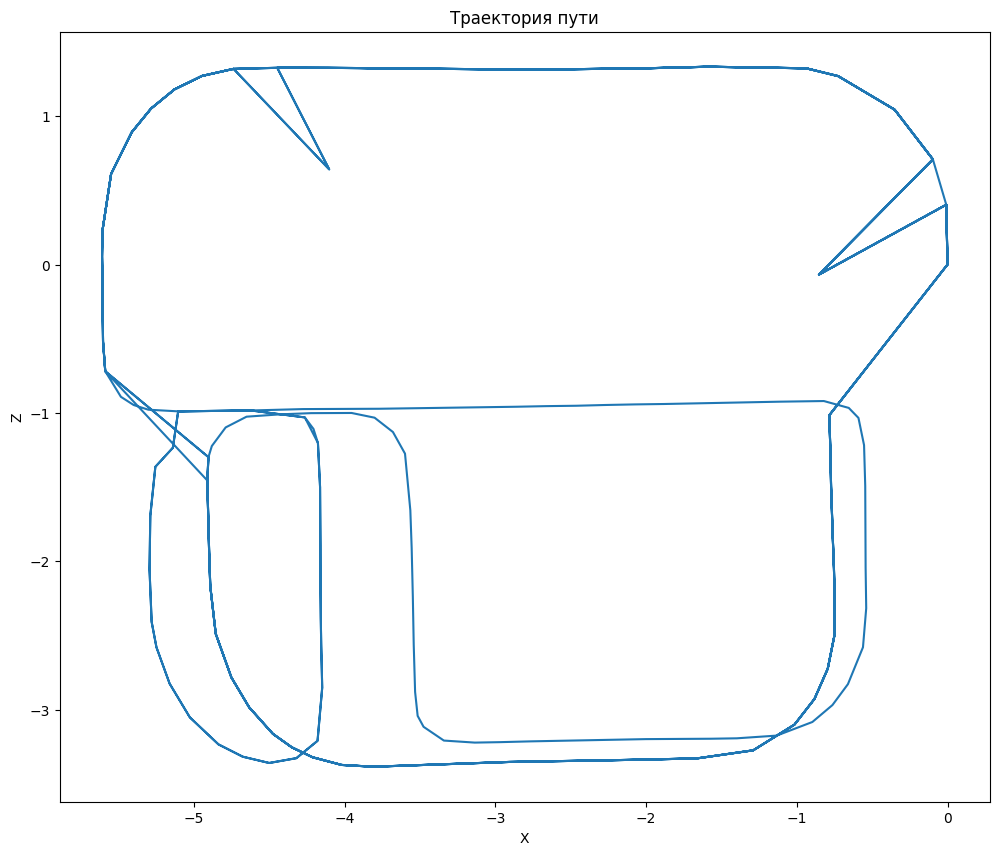

CPU times: total: 8min 3s
Wall time: 1min 5s


In [275]:
%%time

collection_name_system = "carla_data_system_empty"
vector_size = 2048
create_or_replace_collection(collection_name_system, vector_size, replace=True)

positions = test_dataset_on_system(collection_name_system, df_data, images_path, 30, score_threshold=0.70)

Коллекция уже существует
Коллекция удалена


100%|██████████████████████████████████████████████████████████████████████████████| 3599/3599 [03:00<00:00, 19.89it/s]


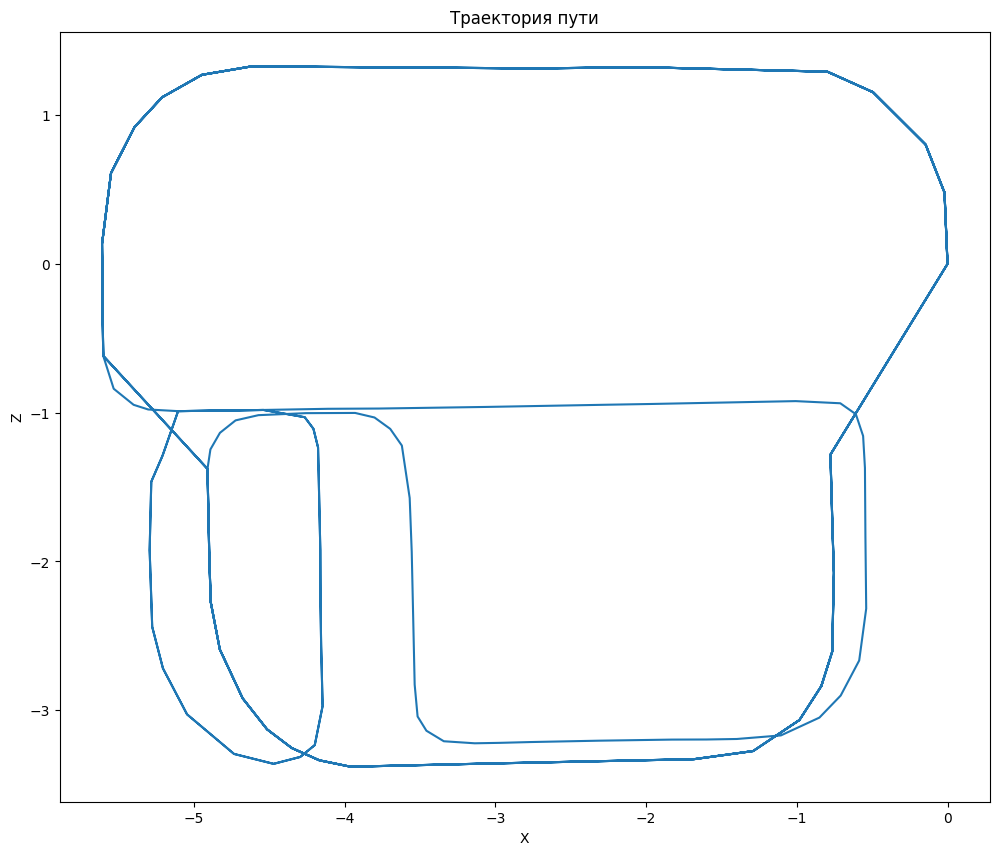

CPU times: total: 22min 48s
Wall time: 3min 2s


In [276]:
%%time

collection_name_system = "carla_data_system_empty"
vector_size = 2048
create_or_replace_collection(collection_name_system, vector_size, replace=True)

positions = test_dataset_on_system(collection_name_system, df_data, images_path, 10, score_threshold=0.60)

Коллекция уже существует
Коллекция удалена


100%|██████████████████████████████████████████████████████████████████████████████| 7197/7197 [06:32<00:00, 18.36it/s]


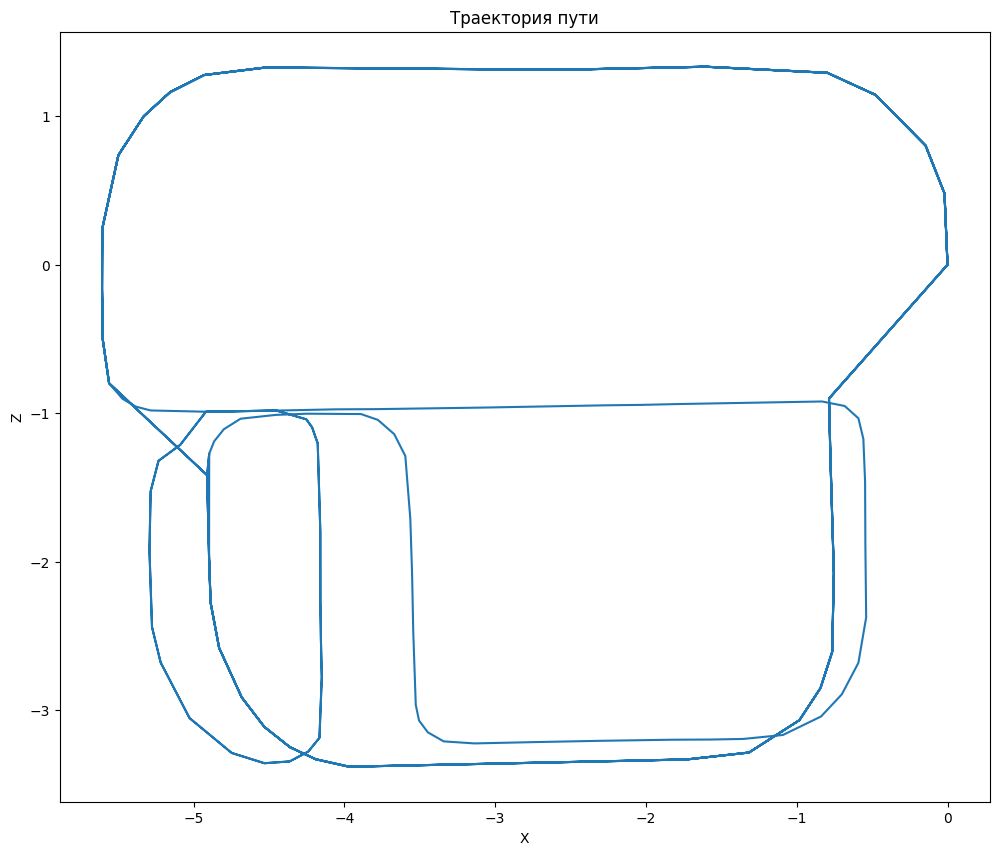

CPU times: total: 49min 33s
Wall time: 6min 33s


In [277]:
%%time

collection_name_system = "carla_data_system_empty"
vector_size = 2048
create_or_replace_collection(collection_name_system, vector_size, replace=True)

positions = test_dataset_on_system(collection_name_system, df_data, images_path, 5, score_threshold=0.60)

## Тестирование

Можно проверить алгоритм на датасете из Kaggle: https://www.kaggle.com/datasets/mbsoroush/car-camera-photos/data.  
У него запись идёт в 30 кадров в секунду.  
Проверка с тем же интервалом на моём датасете:

Коллекция уже существует
Коллекция удалена


100%|██████████████████████████████████████████████████████████████████████████████| 1200/1200 [01:07<00:00, 17.69it/s]


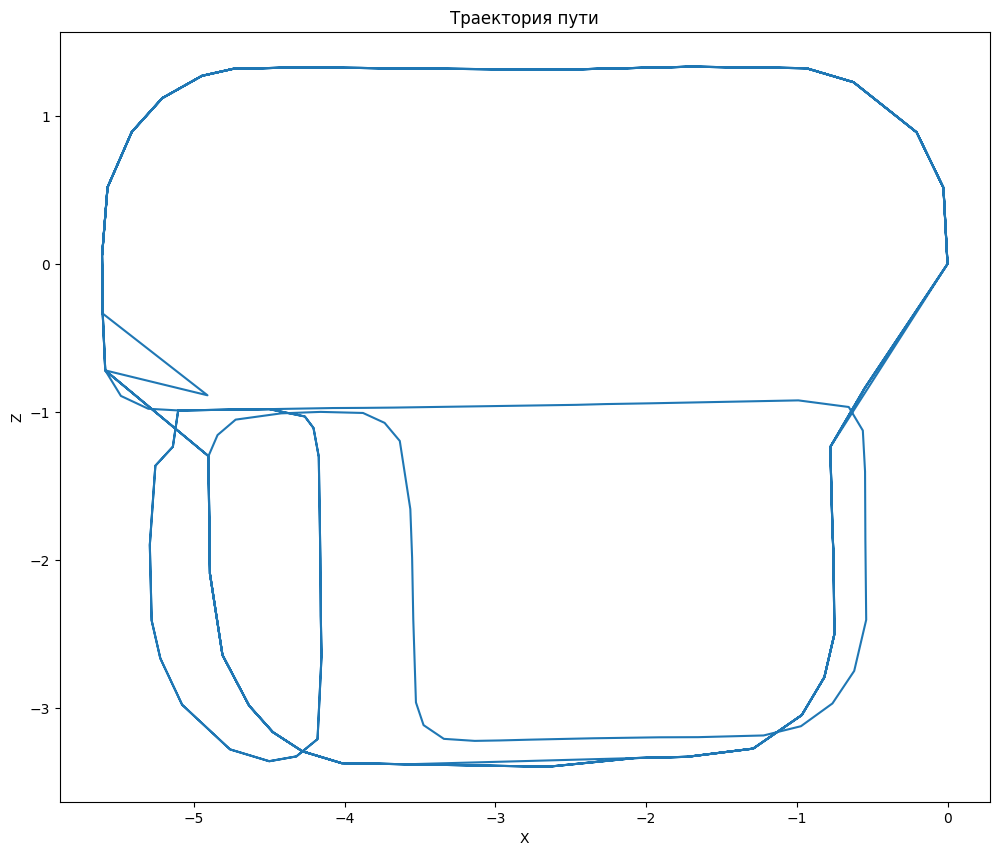

CPU times: total: 8min 33s
Wall time: 1min 8s


In [278]:
%%time

collection_name_system = "carla_data_system_empty"
vector_size = 2048
create_or_replace_collection(collection_name_system, vector_size, replace=True)

positions = test_dataset_on_system(collection_name_system, df_data, images_path, 30, score_threshold=0.60)

# Очистка мусора

In [ ]:
del sam
del predictor
del dino_processor_tiny
del dino_model_tiny

gc.collect()
torch.cuda.empty_cache()